Descriptive Statistics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

# Set random seed for reproducibility
np.random.seed(42)

# Generate a sample sales dataset (normal distribution with some outliers)
regular_sales = np.random.normal(loc=5000, scale=1200, size=95)
outliers = np.array([12000, 13500, 14000, 800, 500]) # Adding high and low outliers

# Combine and create DataFrame
sales_data = np.concatenate([regular_sales, outliers])
df = pd.DataFrame({'Sales': sales_data})

display(df.head())
display(df.describe())

,Sales
0,5596.056984
1,4834.082839
2,5777.226246
3,6827.635828
4,4719.015950


,Sales
count,100.000000
mean,5047.013936
std,1895.404027
min,500.000000
25%,4264.928123
50%,4847.652450
75%,5671.806926
max,14000.000000


1. Measures of Central Tendency

In [2]:
# Mean
mean_sales = df['Sales'].mean()
# Median
median_sales = df['Sales'].median()
# Mode (Rounding to nearest integer for meaningful mode in continuous data)
mode_sales = df['Sales'].round().mode()[0]

print(f"Mean: ${mean_sales:.2f}")
print(f"Median: ${median_sales:.2f}")
print(f"Mode (Rounded): ${mode_sales:.2f}")

Mean: $5047.01
Median: $4847.65
Mode (Rounded): $4719.00


2. Measures of Dispersion & IQR (Outlier Detection)

In [3]:
# Variance and Standard Deviation
variance_sales = df['Sales'].var()
std_dev_sales = df['Sales'].std()

# Range
range_sales = df['Sales'].max() - df['Sales'].min()

# IQR
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)
IQR = Q3 - Q1

print(f"Variance: {variance_sales:.2f}")
print(f"Standard Deviation: ${std_dev_sales:.2f}")
print(f"Range: ${range_sales:.2f}")
print(f"Q1: ${Q1:.2f}, Q3: ${Q3:.2f}, IQR: ${IQR:.2f}")

# Identify Outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_df = df[(df['Sales'] < lower_bound) | (df['Sales'] > upper_bound)]
print(f"\nLower Bound for Outliers: ${lower_bound:.2f}")
print(f"Upper Bound for Outliers: ${upper_bound:.2f}")
print(f"Number of Outliers identified: {len(outliers_df)}")
display(outliers_df)

Variance: 3592556.42
Standard Deviation: $1895.40
Range: $13500.00
Q1: $4264.93, Q3: $5671.81, IQR: $1406.88

Lower Bound for Outliers: $2154.61
Upper Bound for Outliers: $7782.13
Number of Outliers identified: 6


,Sales
74,1856.305875
95,12000.000000
96,13500.000000
97,14000.000000
98,800.000000
99,500.000000


3. Measure of Symmetricity/Shape

In [4]:
skewness = skew(df['Sales'])
kurt = kurtosis(df['Sales'])

print(f"Skewness: {skewness:.2f}")
print(f"Kurtosis: {kurt:.2f}")

Skewness: 2.10
Kurtosis: 8.89


4. Visualizations

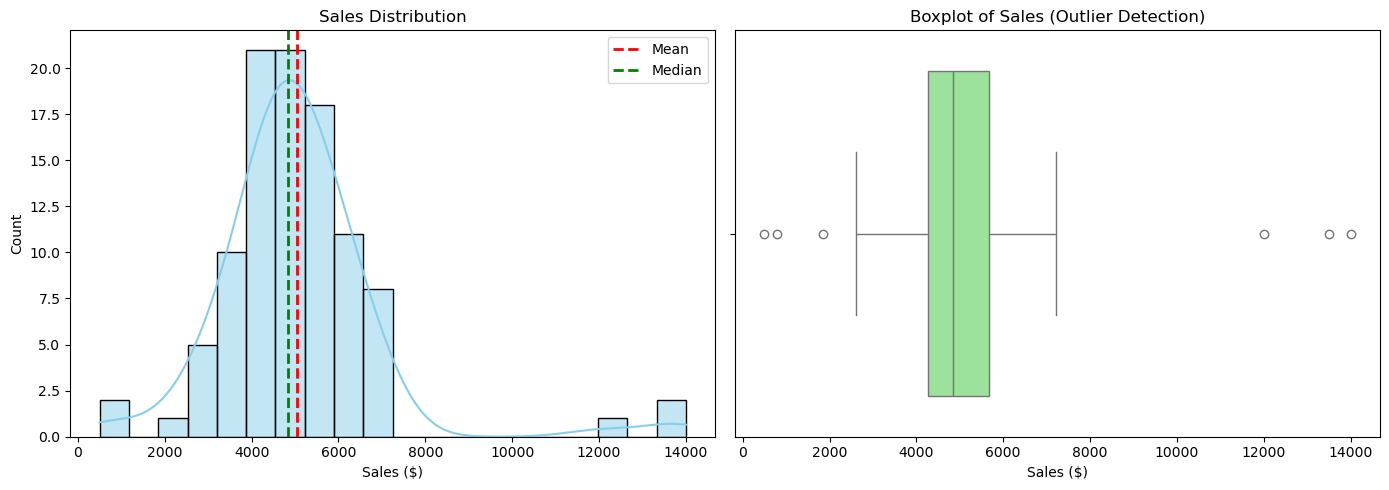

In [5]:
plt.figure(figsize=(14, 5))

# Histogram with KDE
plt.subplot(1, 2, 1)
sns.histplot(df['Sales'], kde=True, bins=20, color='skyblue')
plt.axvline(mean_sales, color='red', linestyle='dashed', linewidth=2, label='Mean')
plt.axvline(median_sales, color='green', linestyle='dashed', linewidth=2, label='Median')
plt.title('Sales Distribution')
plt.xlabel('Sales ($)')
plt.legend()

# Boxplot for IQR and Outliers
plt.subplot(1, 2, 2)
sns.boxplot(x=df['Sales'], color='lightgreen')
plt.title('Boxplot of Sales (Outlier Detection)')
plt.xlabel('Sales ($)')

plt.tight_layout()
plt.show()

Domain 1: Healthcare (Patient Blood Pressure)
**Use Case:** Monitoring systolic blood pressure in a clinic.
**Key Stats:** Mean and Standard Deviation to establish the "normal" range. Outliers help identify patients needing immediate medical intervention (hypertension/hypotension).

In [6]:
# Healthcare Data Simulation
bp_data = np.random.normal(loc=120, scale=12, size=200) # Normal BP around 120
bp_outliers = np.array([180, 195, 80, 75]) # Critical patients
bp_df = pd.DataFrame({'Systolic_BP': np.concatenate([bp_data, bp_outliers])})

print("--- Healthcare: Blood Pressure ---")
print(f"Mean BP: {bp_df['Systolic_BP'].mean():.2f}")
print(f"Standard Deviation: {bp_df['Systolic_BP'].std():.2f}")
# Identifying outliers (e.g., > 140 is typically high BP)
print(f"Patients with Critical BP (>160 or <90): {len(bp_df[(bp_df['Systolic_BP'] > 160) | (bp_df['Systolic_BP'] < 90)])}")

--- Healthcare: Blood Pressure ---
Mean BP: 120.58
Standard Deviation: 14.48
Patients with Critical BP (>160 or <90): 6


Domain 2: Finance (Daily Stock Returns)
**Use Case:** Analyzing the risk and volatility of a financial portfolio.
**Key Stats:** Kurtosis and Skewness. High kurtosis (fat tails) indicates a higher risk of extreme market events (black swans).

In [9]:
# Finance Data Simulation (Laplace distribution creates 'fat tails' common in finance)
stock_returns = np.random.laplace(loc=0.001, scale=0.02, size=252) # 252 trading days
returns_df = pd.DataFrame({'Daily_Return': stock_returns})

print("--- Finance: Stock Returns ---")
print(f"Skewness: {skew(returns_df['Daily_Return']):.2f} (Symmetry of returns)")
print(f"Kurtosis: {kurtosis(returns_df['Daily_Return']):.2f} (Risk of extreme market swings)")

--- Finance: Stock Returns ---
Skewness: 0.22 (Symmetry of returns)
Kurtosis: 1.41 (Risk of extreme market swings)


Domain 3: Education (Student Exam Scores)
**Use Case:** Evaluating a class's performance on a standardized test.
**Key Stats:** Median and IQR. The median is resistant to a few students scoring zero, providing a better baseline of the typical student's understanding.

In [8]:
# Education Data Simulation
scores = np.random.normal(loc=75, scale=10, size=50)
scores = np.clip(scores, 0, 100) # Scores must be between 0 and 100
scores_df = pd.DataFrame({'Exam_Score': scores})

q1, q3 = scores_df['Exam_Score'].quantile(0.25), scores_df['Exam_Score'].quantile(0.75)

print("--- Education: Exam Scores ---")
print(f"Median Score: {scores_df['Exam_Score'].median():.2f}")
print(f"Interquartile Range (IQR): {(q3 - q1):.2f} (Spread of the middle 50% of students)")

--- Education: Exam Scores ---
Median Score: 74.97
Interquartile Range (IQR): 12.96 (Spread of the middle 50% of students)


Domain 4: Manufacturing (Quality Control tolerances)
**Use Case:** Machining metal shafts to a specific diameter (e.g., 50mm).
**Key Stats:** Variance and Range. High variance means the machines are losing precision, leading to defective parts that don't fit.

In [7]:
# Manufacturing Data Simulation
part_diameters = np.random.normal(loc=50.0, scale=0.05, size=500) # Target 50mm, slight variance
mfg_df = pd.DataFrame({'Diameter_mm': part_diameters})

print("--- Manufacturing: Quality Control ---")
print(f"Variance: {mfg_df['Diameter_mm'].var():.5f} (Machining precision)")
print(f"Range: {(mfg_df['Diameter_mm'].max() - mfg_df['Diameter_mm'].min()):.4f} mm (Difference between largest and smallest part)")

--- Manufacturing: Quality Control ---
Variance: 0.00243 (Machining precision)
Range: 0.2888 mm (Difference between largest and smallest part)


Domain 5: E-commerce (Website 'Time on Page')
**Use Case:** Analyzing how long users stay on a product page.
**Key Stats:** Skewness. Web analytics almost always follow a right-skewed distribution where most users bounce quickly, but a few read every word.

In [10]:
# E-commerce Data Simulation (Exponential distribution creates a strong right skew)
time_on_page = np.random.exponential(scale=45, size=1000) # Average 45 seconds
ecom_df = pd.DataFrame({'Time_Seconds': time_on_page})

print("--- E-commerce: Time on Page ---")
print(f"Mean Time: {ecom_df['Time_Seconds'].mean():.1f}s vs Median Time: {ecom_df['Time_Seconds'].median():.1f}s")
print(f"Skewness: {skew(ecom_df['Time_Seconds']):.2f} (Highly right-skewed distribution)")

--- E-commerce: Time on Page ---
Mean Time: 44.8s vs Median Time: 31.9s
Skewness: 1.99 (Highly right-skewed distribution)


Comparative Summary Table
Comparing the Mean and Variance across all 5 domains.

In [11]:
summary_data = {
    'Domain': [
        'Healthcare (Systolic BP)',
        'Finance (Daily Returns)',
        'Education (Exam Scores)',
        'Manufacturing (Diameter mm)',
        'E-commerce (Time on Page s)'
    ],
    'Mean': [
        bp_df['Systolic_BP'].mean(),
        returns_df['Daily_Return'].mean(),
        scores_df['Exam_Score'].mean(),
        mfg_df['Diameter_mm'].mean(),
        ecom_df['Time_Seconds'].mean()
    ],
    'Variance': [
        bp_df['Systolic_BP'].var(),
        returns_df['Daily_Return'].var(),
        scores_df['Exam_Score'].var(),
        mfg_df['Diameter_mm'].var(),
        ecom_df['Time_Seconds'].var()
    ]
}

summary_df = pd.DataFrame(summary_data)
display(summary_df.round(4))

,Domain,Mean,Variance
0,Healthcare (Systolic BP),120.5761,209.6716
1,Finance (Daily Returns),0.0014,0.0008
2,Education (Exam Scores),76.1534,74.4432
3,Manufacturing (Diameter mm),49.9996,0.0024
4,E-commerce (Time on Page s),44.8304,2005.2790
